## Часть 1

In [2]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

### Описательные статистики
Источник данных: https://tochno.st/datasets/regions_collection - социально-экономические показатели регионов России.

In [3]:
economics_df = pd.read_csv("data/data_regions_collection_102_v20250605.csv", sep=";")

Группировка данных оборота розничной торговли организаций потребительской кооперации по регионам:

In [4]:
consumption = economics_df[(economics_df["section"] == "Потребительский рынок")
           & (economics_df["subsection"] == "Млн руб.")
           & (economics_df["object_level"] == "регион")][["object_name", "indicator_value"]]
consumption_grouped = consumption.groupby("object_name")["indicator_value"].mean()
consumption_grouped = consumption_grouped[consumption_grouped > 0.0] # удаление выбросов (отрицательных значений)

Основные статистики:

In [5]:
pd.DataFrame(consumption_grouped).describe()

,indicator_value
count,80.000000
mean,1473.622500
std,1719.594953
min,4.700000
25%,280.950000
50%,790.100000
75%,2257.025000
max,8101.600000


In [6]:
consumption_grouped[(consumption_grouped == min(consumption_grouped))
                  | (consumption_grouped == max(consumption_grouped))]

object_name
Вологодская область             8101.6
Еврейская автономная область       4.7
Name: indicator_value, dtype: float64

* Четверть регионов имеет годовой оборот розничной торговли до 280 млн. руб.

* Четверть регионов с крупнейшей розничной торговлей имеет оборот выше 2 млрд. 257 млн. руб

* В наборе представлены данные c 80 регионов.

* Средний размер годового оборота розничной торговли равен 1 млрд. 473 млн. руб.

* Минимальный годовой оборот зафиксирован в Еврейской автономной области (4.7 млн. руб.)

* Максимальный -- в Вологодской области (8 млрд. 101 млн 600 тыс. руб)

* В половине регионов РФ годовой оборот не превышает 790 млн. руб.

In [7]:
variation = stats.tvar(consumption_grouped) # дисперсия
skewness = stats.skew(consumption_grouped) # ассиметрия
kurtosis = stats.kurtosis(consumption_grouped) # эксцесс
mode = stats.mode(consumption_grouped.astype(int)) # мода округлена до целых, иначе каждое значение встречается по одному разу

print(f"""
    Дисперсия: {variation} млн. руб.
    Коэффициент асимметрии: {round(skewness, 3)}
    Эксцесс: {round(kurtosis, 3)}
    Мода: {mode}""")


    Дисперсия: 2957006.801512658 млн. руб.
    Коэффициент асимметрии: 1.734
    Эксцесс: 2.725
    Мода: ModeResult(mode=np.int64(199), count=np.int64(2))


Коэффициент ассиметрии > 0 -- правосторонняя асимметрия

Коэффициент эксцесса > 0 -- распределение островершинное

### Законы распределения

#### Распределение Фишера

In [8]:
ps = [0.9, 0.95, 0.99]

In [9]:
def draw_plot(x, df1, df2, pdf, cdf, axe, row):

    # График плотности (PDF)
    axe[row, 0].plot(x, pdf, 'r-', lw=2)
    axe[row, 0].set_title(f'({df1}, {df2})')
    axe[row, 0].grid(True, alpha=0.3)

    # График функции распределения (CDF)
    axe[row, 1].plot(x, cdf, 'b-', lw=2)
    axe[row, 1].set_title(f'({df1}, {df2})')
    axe[row, 1].grid(True, alpha=0.3)

df1=10 df2=10
              f-статистика: 2.323
              p-value: 0.1
df1=10 df2=10
              f-статистика: 2.978
              p-value: 0.05
df1=10 df2=10
              f-статистика: 4.849
              p-value: 0.01
df1=2 df2=50
              f-статистика: 2.412
              p-value: 0.1
df1=2 df2=50
              f-статистика: 3.183
              p-value: 0.05
df1=2 df2=50
              f-статистика: 5.057
              p-value: 0.01
df1=10 df2=50
              f-статистика: 1.729
              p-value: 0.1
df1=10 df2=50
              f-статистика: 2.026
              p-value: 0.05
df1=10 df2=50
              f-статистика: 2.698
              p-value: 0.01
df1=10 df2=500
              f-статистика: 1.612
              p-value: 0.1
df1=10 df2=500
              f-статистика: 1.85
              p-value: 0.05
df1=10 df2=500
              f-статистика: 2.356
              p-value: 0.01
df1=30 df2=1000
              f-статистика: 1.35
              p-value: 0.1
df1=30 df2=1000
 

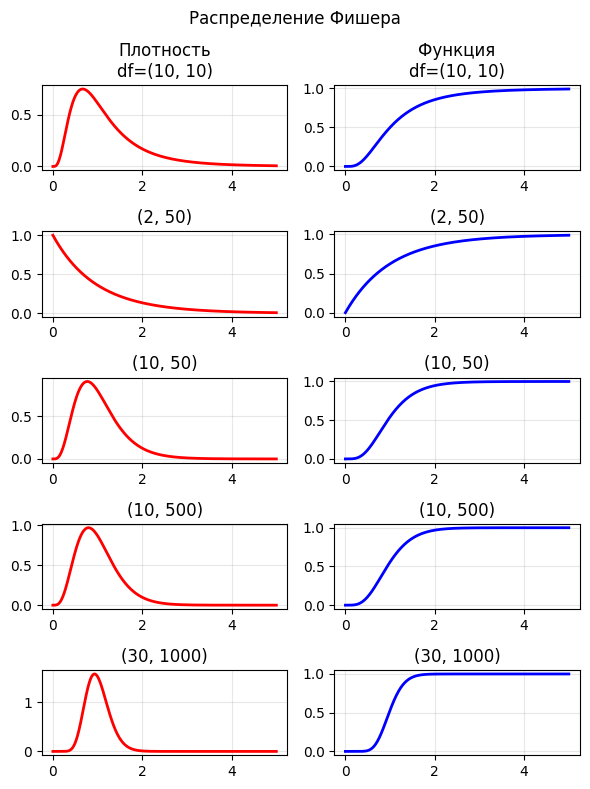

In [40]:
from scipy.stats import f

x = np.linspace(0, 5, 500)

dfs = [(10, 10), (2, 50), (10, 50), (10, 500), (30, 1000)]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8))
row_num = 0
for df1, df2 in dfs:
    pdf = f.pdf(x, df1, df2) # Плотность вероятности
    cdf = f.cdf(x, df1, df2) # Функция распределения
    draw_plot(x, df1, df2, pdf, cdf, axes, row_num)
    row_num += 1

    for p in ps:
        f_stat = round(f.ppf(p, df1, df2), 3)
        print(f"""df1={df1} df2={df2}
              f-статистика: {f_stat}
              p-value: {round(f.sf(f_stat, df1, df2), 3)}""")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Распределение Фишера")
fig.tight_layout()

Распределение всегда имеет положительную правостороннюю асимметрию. Коэффициент асимметрии уменьшается с ростом df1, df2 и распределение постепенно приближается к нормальному.

#### Распределение Стьюдента

In [11]:
def draw_t_plot(x, df1, pdf, cdf, axe, row):

    axe[row, 0].plot(x, pdf, 'r-', lw=2)
    axe[row, 0].set_title(f'df={df1}')
    axe[row, 0].grid(True, alpha=0.3)

    axe[row, 1].plot(x, cdf, 'b-', lw=2)
    axe[row, 1].set_title(f'df={df1}')
    axe[row, 1].grid(True, alpha=0.3)

df1=10
              t-статистика: 1.372
              p-value: 0.1
df1=10
              t-статистика: 1.812
              p-value: 0.05
df1=10
              t-статистика: 2.764
              p-value: 0.01
df1=50
              t-статистика: 1.299
              p-value: 0.1
df1=50
              t-статистика: 1.676
              p-value: 0.05
df1=50
              t-статистика: 2.403
              p-value: 0.01
df1=200
              t-статистика: 1.286
              p-value: 0.1
df1=200
              t-статистика: 1.653
              p-value: 0.05
df1=200
              t-статистика: 2.345
              p-value: 0.01


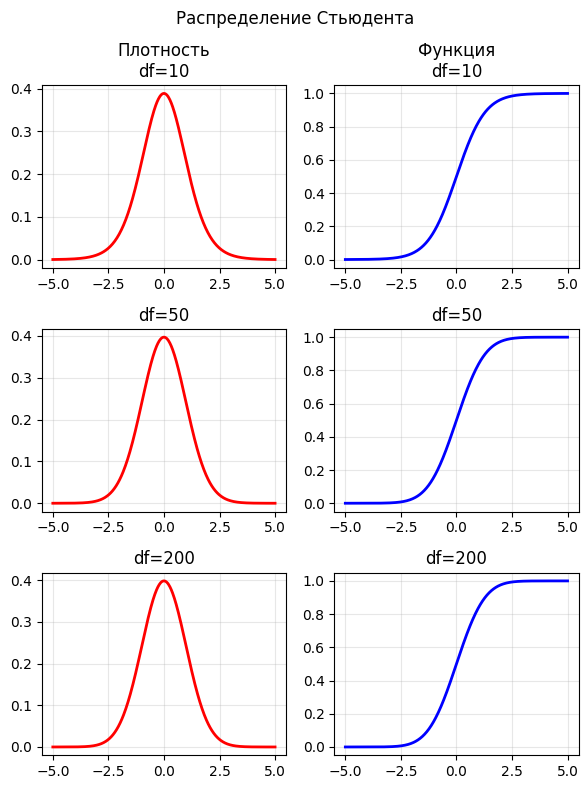

In [39]:
from scipy.stats import t
x = np.linspace(-5, 5, 500)

dfs = [10, 50, 200]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8))
row_num = 0
for df1 in dfs:
    pdf = t.pdf(x, df1) # Плотность вероятности
    cdf = t.cdf(x, df1) # Функция распределения
    draw_t_plot(x, df1, pdf, cdf, axes, row_num)
    row_num += 1

    for p in ps:
        t_stat = round(t.ppf(p, df1), 3)
        print(f"""df1={df1}
              t-статистика: {t_stat}
              p-value: {round(t.sf(t_stat, df1), 3)}""")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Распределение Стьюдента")
fig.tight_layout()

С ростом степени свободы распределение приближается к нормальному.

#### Показательное распределение

df1=0.5
              exp-статистика: 2.803
              p-value: 0.1
df1=0.5
              exp-статистика: 3.496
              p-value: 0.05
df1=0.5
              exp-статистика: 5.105
              p-value: 0.01
df1=5.0
              exp-статистика: 7.303
              p-value: 0.1
df1=5.0
              exp-статистика: 7.996
              p-value: 0.05
df1=5.0
              exp-статистика: 9.605
              p-value: 0.01
df1=20.0
              exp-статистика: 22.303
              p-value: 0.1
df1=20.0
              exp-статистика: 22.996
              p-value: 0.05
df1=20.0
              exp-статистика: 24.605
              p-value: 0.01


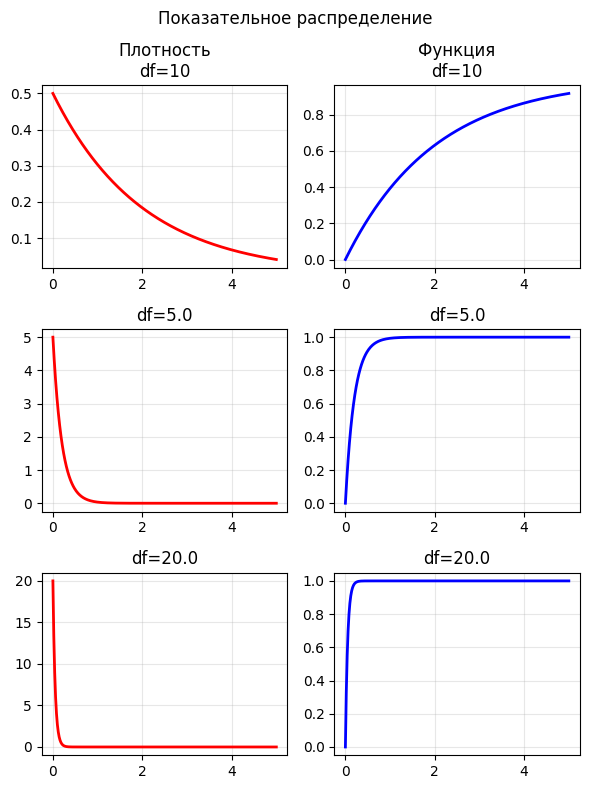

In [38]:
from scipy.stats import expon

x = np.linspace(0, 5, 500)
lambdas = [0.5, 5.0, 20.0]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8))
row_num = 0
for df1 in lambdas:
    pdf = expon.pdf(x, scale=1/df1) # Плотность вероятности
    cdf = expon.cdf(x, scale=1/df1) # Функция распределения
    draw_t_plot(x, df1, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        exp_stat = round(expon.ppf(p, df1), 3)
        print(f"""df1={df1}
              exp-статистика: {exp_stat}
              p-value: {round(expon.sf(exp_stat, df1), 3)}""")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Показательное распределение")
fig.tight_layout()

При малом $\lambda = 0.5$: График плотности спадает очень медленно, «хвост» распределения тянется вправо, что описывает редкие события.

При большом $\lambda = 20/0$: Функция и плотность быстро приближаются к пределу. Вероятность того, что случайная величина примет значение больше 0.5, стремится к нулю, что описывает частые события.

#### $\chi^2$-распределение

df1=10
              хи-квадрат статистика: 15.987
              p-value: 0.1
df1=10
              хи-квадрат статистика: 18.307
              p-value: 0.05
df1=10
              хи-квадрат статистика: 23.209
              p-value: 0.01
df1=50
              хи-квадрат статистика: 63.167
              p-value: 0.1
df1=50
              хи-квадрат статистика: 67.505
              p-value: 0.05
df1=50
              хи-квадрат статистика: 76.154
              p-value: 0.01
df1=200
              хи-квадрат статистика: 226.021
              p-value: 0.1
df1=200
              хи-квадрат статистика: 233.994
              p-value: 0.05
df1=200
              хи-квадрат статистика: 249.445
              p-value: 0.01


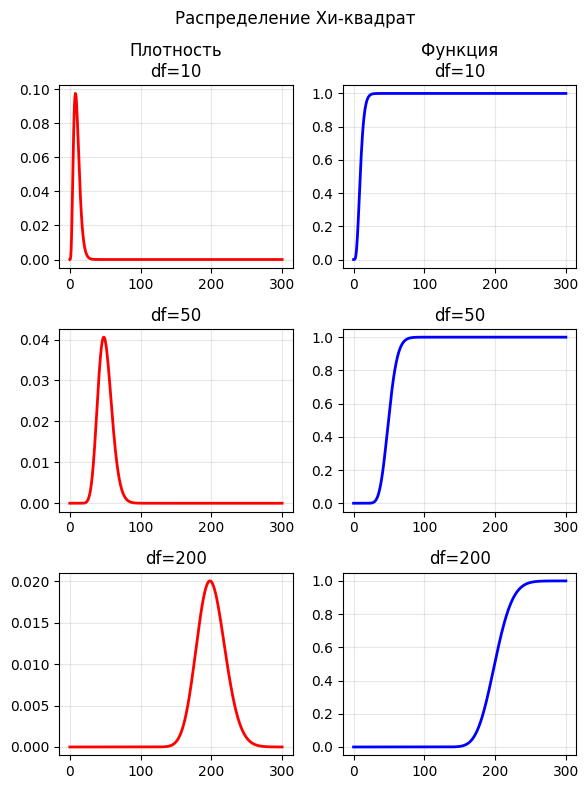

In [37]:
from scipy.stats import chi2
x = np.linspace(0, 300, 500)

dfs = [10, 50, 200]

fig, axes = plt.subplots(len(dfs), 2, figsize=(6, 8))
row_num = 0
for df1 in dfs:
    pdf = chi2.pdf(x, df1) # Плотность вероятности
    cdf = chi2.cdf(x, df1) # Функция распределения
    draw_t_plot(x, df1, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        chi2_stat = round(chi2.ppf(p, df1), 3)
        print(f"""df1={df1}
              хи-квадрат статистика: {chi2_stat}
              p-value: {round(chi2.sf(chi2_stat, df1), 3)}""")

axes[0, 0].set_title(f"Плотность\ndf={dfs[0]}")
axes[0, 1].set_title(f"Функция\ndf={dfs[0]}")
fig.suptitle("Распределение Хи-квадрат")
fig.tight_layout()

При малых степенях свободы распределение имеет сильную правостороннюю асимметрию -- хвост вправо. С ростом df распределение становится все более симметричным.

 #### Логнормальное распределение

df1=30
              lognorm-статистика: 4.602
              p-value: 0.48
df1=30
              lognorm-статистика: 6.18
              p-value: 0.476
df1=30
              lognorm-статистика: 11.24
              p-value: 0.468
df1=30
              lognorm-статистика: 15.694
              p-value: 0.463
df1=30
              lognorm-статистика: 29.553
              p-value: 0.455
df1=30
              lognorm-статистика: 107.586
              p-value: 0.438


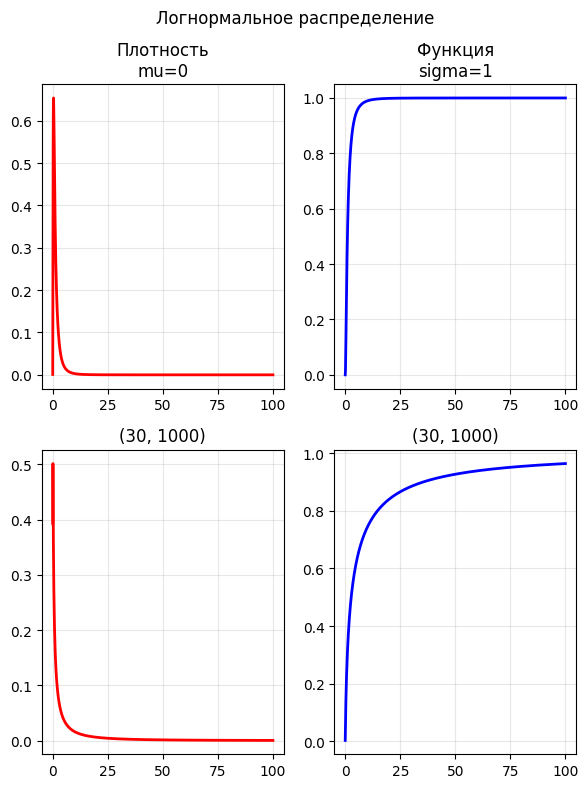

In [42]:
from scipy.stats import lognorm

x = np.linspace(0.01, 100, 1000)

params = [(0, 1), (1, 2)]

fig, axes = plt.subplots(len(params), 2, figsize=(6, 8))
row_num = 0
for mu, sigma in params:
    pdf = lognorm.pdf(x, s=sigma, scale=np.exp(mu)) # Плотность вероятности
    cdf = lognorm.cdf(x, s=sigma, scale=np.exp(mu)) # Функция распределения
    draw_plot(x, df1, df2, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        lognorm_stat = round(lognorm.ppf(p, sigma, np.exp(mu)), 3)
        print(f"""df1={df1}
              lognorm-статистика: {lognorm_stat}
              p-value: {round(lognorm.sf(lognorm_stat, df1), 3)}""")

axes[0, 0].set_title(f"Плотность\nmu={params[0][0]}")
axes[0, 1].set_title(f"Функция\nsigma={params[0][1]}")
fig.suptitle("Логнормальное распределение")
fig.tight_layout()

При малых $\sigma$ распределение похоже на нормальное.

При больших $\sigma$ пик становится очень высоким и резко смещается к нулю. Это описывает процессы с редкими, но огромными выбросами.

#### Нормальное распределение

mu=0, sigma=1
статистика: 1.282
p-value: 0.1
mu=0, sigma=1
статистика: 1.645
p-value: 0.05
mu=0, sigma=1
статистика: 2.326
p-value: 0.01
mu=1, sigma=2
статистика: 3.563
p-value: 0.1
mu=1, sigma=2
статистика: 4.29
p-value: 0.05
mu=1, sigma=2
статистика: 5.653
p-value: 0.01


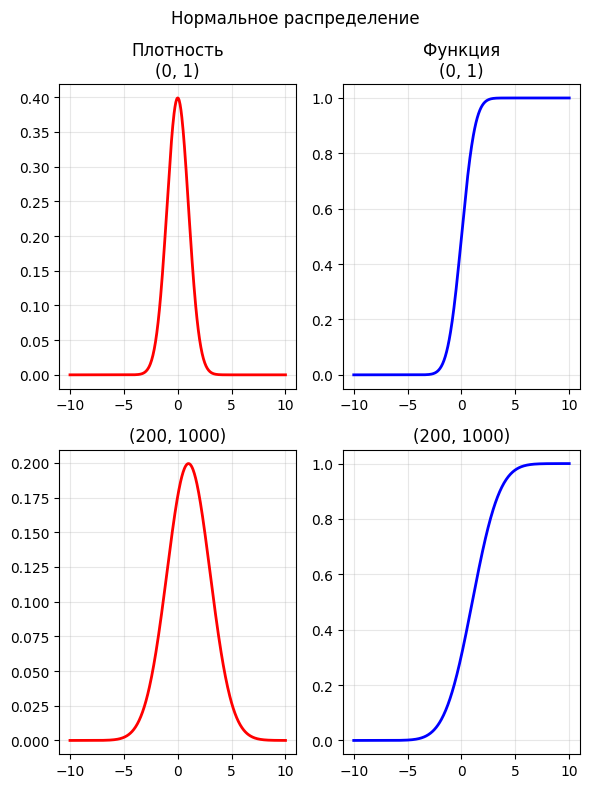

In [36]:
from scipy.stats import norm

x = np.linspace(-10, 10, 500)

params = [(0, 1), (1, 2)]

fig, axes = plt.subplots(len(params), 2, figsize=(6, 8))
row_num = 0
for mu, sigma in params:
    pdf = norm.pdf(x, loc=mu, scale=sigma) # Плотность вероятности
    cdf = norm.cdf(x, loc=mu, scale=sigma) # Функция распределения
    draw_plot(x, df1, df2, pdf, cdf, axes, row_num)
    row_num += 1
    for p in ps:
        norm_stat = norm.ppf(p, scale=sigma, loc=mu)
        print(f"""mu={mu}, sigma={sigma}
статистика: {round(norm_stat, 3)}
p-value: {round(norm.sf(norm_stat, loc=mu, scale=sigma), 3)}""")
axes[0, 0].set_title(f"Плотность\n{params[0]}")
axes[0, 1].set_title(f"Функция\n{params[0]}")
fig.suptitle("Нормальное распределение")
fig.tight_layout()